# **From Biological to Artificial Neurons**

## **The Perceptron**

1. A perceptron is the most fundamental building block of neural networks and a foundational algorithm in machine learning for binary classification
It answers a yes/no (0/1 or −1/+1) decision question.

$$\hat{y} = sign(W^{T}X + b)$$

2. Activation function:
$$\hat{y} = \begin{cases}1 & \text{if } z \geq 0 \\0 & \text{if } z < 0 \end{cases}$$

3. Learning rule:
$$w_{i,j}^{(next step)} = w_{i,j} + n(y_{j} - \hat{y_{j}})x_{i}$$


In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # setosa

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers

In [3]:
y_pred

array([ True, False])

The Perceptron is equivalent to a SGDClassifier with loss="perceptron", no regularization, and a constant learning rate equal to 1:

In [4]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None, learning_rate="constant", eta0=1, random_state=42)
sgd_clf.fit(X, y)

assert (sgd_clf.coef_ == per_clf.coef_).all()
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

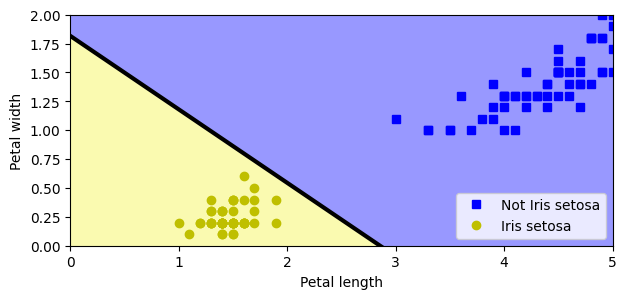

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)

X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-", linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

**Activation Functions**

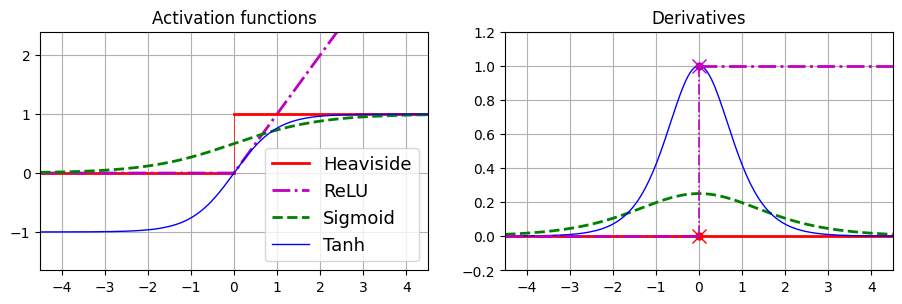

In [6]:
from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

plt.show()

### **MLPs (Multi Layer Preceptron)**

#### **Regression MLPs**

In [7]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42, )
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)

In [9]:
rmse

0.5053326657968533

#### **Classification MLPs**

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

iris = load_iris()
X_train_full, X_test, y_train_full, y_test = train_test_split(iris.data, iris.target, test_size=0.1, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)

mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000, random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_valid, y_valid)

accuracy

1.0

# **Implementing MLPs with Keras**

## **Imports**

1. Keras using CPU - pip install tensorflow
2. keras using GPU - it is build in requires NVIDIA GPUs

In [11]:
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)

c:\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.

2.20.0
3.13.0


c:\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## **1. Building and simple image classifiers using keras**

### **a. defining the model**

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in tf.keras.datasets. The dataset is already split for you between a training set (60,000 images) and a test set (10,000 images), but it can be useful to split the training set further to have a validation set. We'll use 55,000 images for training, and 5,000 for validation.

In [12]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

The training set contains 60,000 grayscale images, each 28x28 pixels:

In [13]:
X_train.shape

(55000, 28, 28)

Each pixel intensity is represented as a byte (0 to 255):

In [14]:
X_train.dtype

dtype('uint8')

Let's scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255:

In [15]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

You can plot an image using Matplotlib's imshow() function, with a 'binary' color map:

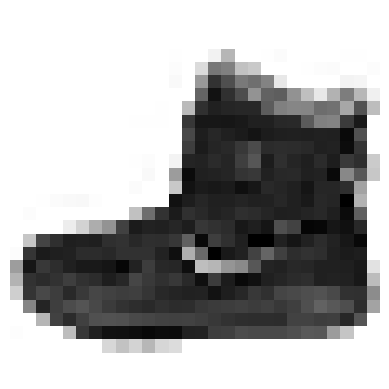

In [16]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [17]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

In [18]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

 the first image in the training set represents a Ankle boot:

In [19]:
class_names[y_train[0]]

'Ankle boot'

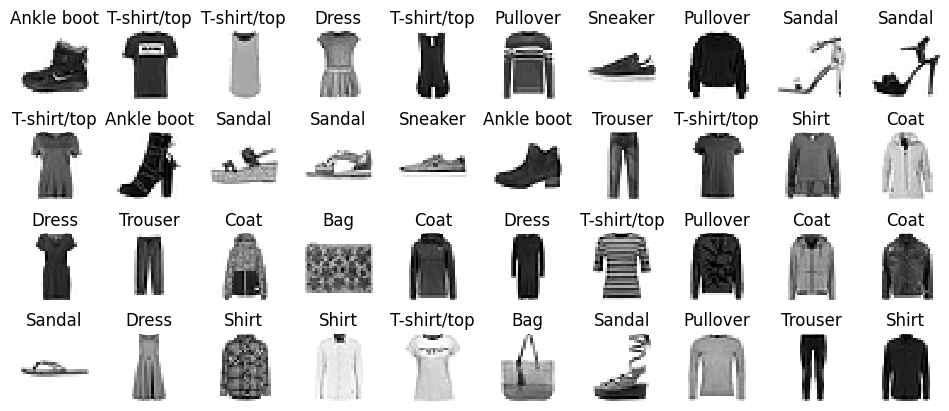

In [20]:
n_rows = 4
n_cols = 10

plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index+1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

In [21]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
# input layer
model.add(tf.keras.layers.InputLayer(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
# two hidden layers with 300 and 100 neurons
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
# output layer with 10 neurons
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

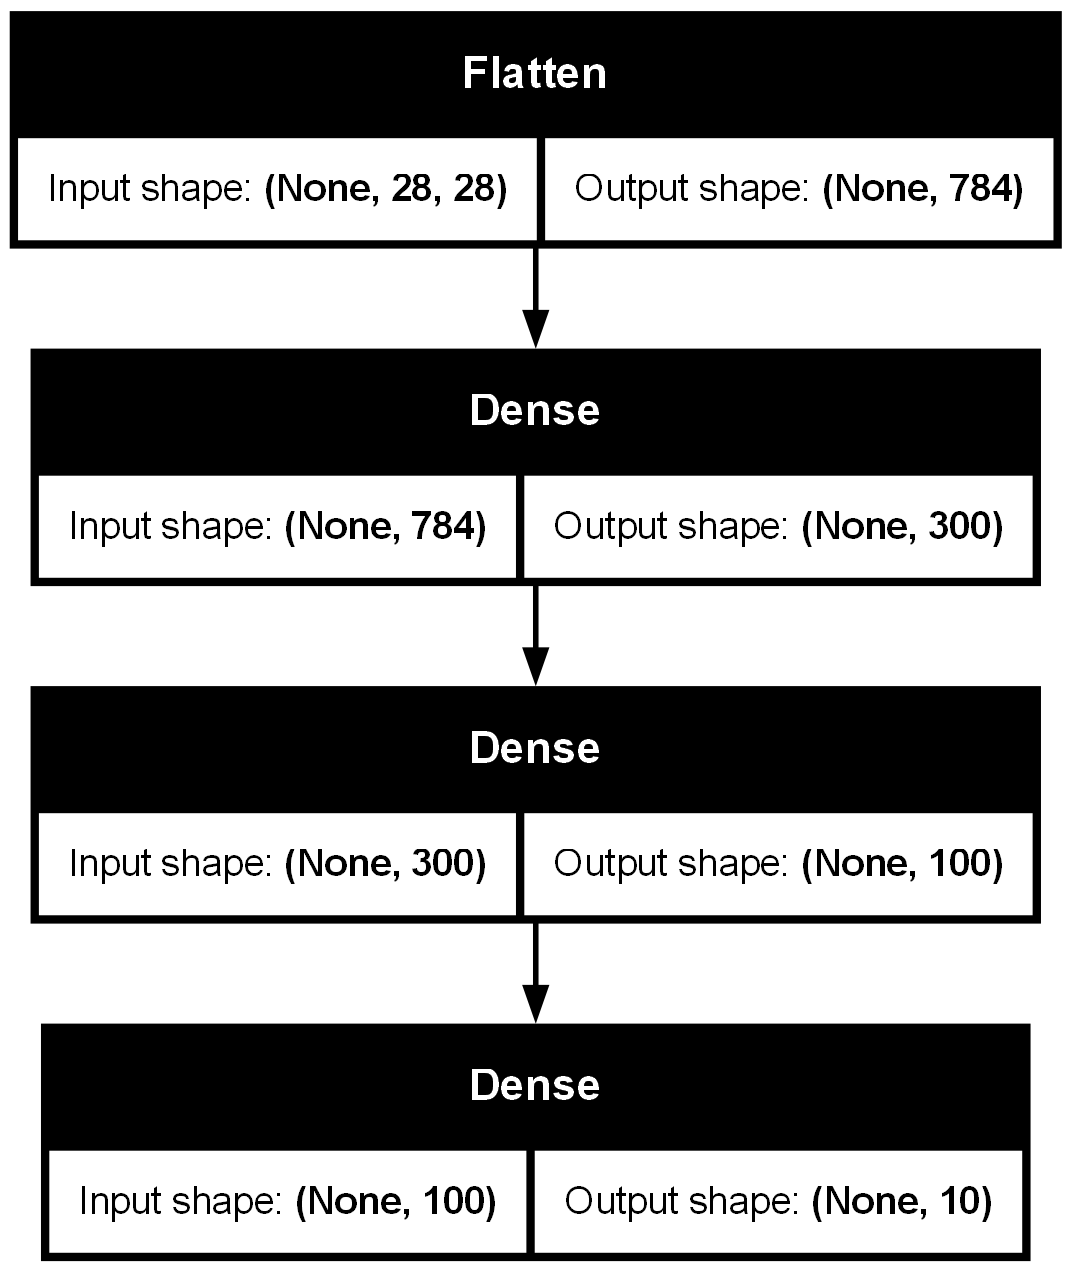

In [25]:
# another way to display the model's architecture
tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

You can easily get a model’s list of layers, to fetch a layer by its index, or you can fetch
it by name:

In [26]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [27]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [28]:
model.get_layer('dense') is hidden1

True

weights and bais terms

In [29]:
weights, biases = hidden1.get_weights()

print(weights)
print(weights.shape)
print('-' * 80)
print(biases)
print(biases.shape)

[[-0.05737878  0.00346926 -0.02327859 ...  0.06710352 -0.07417758
  -0.03134481]
 [-0.07087073  0.03073085  0.06557307 ... -0.01969819 -0.01361017
   0.03551973]
 [-0.03765803 -0.06835759 -0.04293577 ... -0.07391905  0.06692378
  -0.03116486]
 ...
 [-0.0323606   0.03331882 -0.0590493  ...  0.01919147 -0.01478966
  -0.0554809 ]
 [ 0.05187884  0.03699657 -0.06850912 ... -0.00227183 -0.04289611
  -0.05467007]
 [ 0.05766761 -0.06989614  0.05869251 ...  0.0726224   0.06435479
   0.03437493]]
(784, 300)
--------------------------------------------------------------------------------
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

### **b. Compiling the model**

In [30]:
model.compile(
    optimizer="sgd",
    loss='spare_categorical_crossentropy',
    metrics=["accuracy"]
)

1. First, we use the "sparse_categorical_cross entropy" loss because we have sparse labels (i.e., for each instance, there is just a target class index, from 0 to 9 in this case)

2.  If instead we had one target probability per class for each instance (such as one-hot vectors, e.g. [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.] to represent class 3), then we would need to use the "categorical_crossentropy" loss instead.

3. If we were doing binary classification (with one or more binary labels), then we would use the "sigmoid" activation function in the output layer instead of the "softmax" activation function, and we would use the "binary_crossentropy" loss

This is equivalent to:

In [31]:
# this cell is equivalent to the previous cell
model.compile(
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=[tf.keras.metrics.sparse_categorical_accuracy]
)

In [32]:
# convert class ids to one-hot vectors
tf.keras.utils.to_categorical([0, 5, 1, 0], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [33]:
# convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0], dtype=int64)

### **c. Training and evaluating the model**

In [34]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7048 - sparse_categorical_accuracy: 0.7670 - val_loss: 0.4983 - val_sparse_categorical_accuracy: 0.8338
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4820 - sparse_categorical_accuracy: 0.8335 - val_loss: 0.4493 - val_sparse_categorical_accuracy: 0.8396
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4381 - sparse_categorical_accuracy: 0.8485 - val_loss: 0.4280 - val_sparse_categorical_accuracy: 0.8450
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4115 - sparse_categorical_accuracy: 0.8565 - val_loss: 0.4138 - val_sparse_categorical_accuracy: 0.8504
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3920 - sparse_categorical_accuracy: 0.8630 - val_loss: 0.4031 - val_sparse_categorical_accuracy: 0.8540
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3760 - sparse_categorical_accuracy: 0.8683 - val_loss: 0.3939 - val_sparse_categorical_accuracy:

In [35]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [36]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


history.history containing the loss and extra metrics it measured at the end of each epoch on the training set and on the validation set

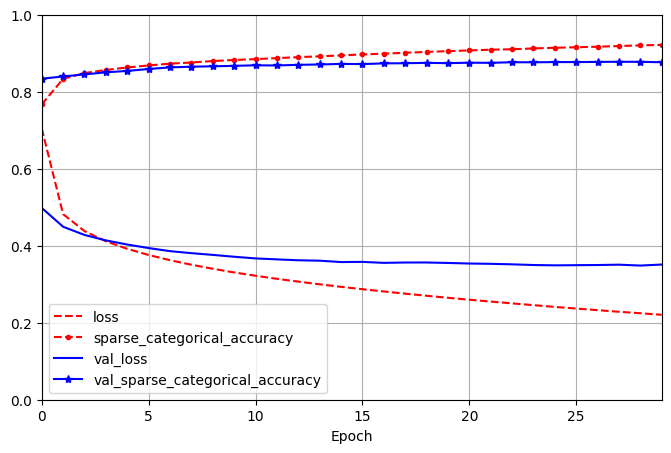

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"]
)
plt.legend(loc="lower left")

plt.show()

You can see that both the training accuracy and the validation accuracy steadily
increase during training, while the training loss and the validation loss decrease.

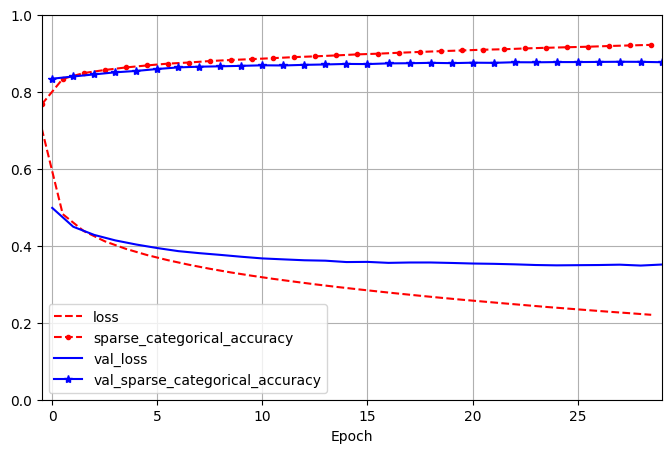

In [38]:
# shows how to shift the training curve by -1/2 epoch
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()

plt.show()

In [39]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3623 - sparse_categorical_accuracy: 0.8713


[0.36232346296310425, 0.8712999820709229]

### **d. Using the model to make predictions**

In [40]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.16, 0.  , 0.01, 0.  , 0.83],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

The model predict the first image as class 9 with highest probaility which is ankel boot 2 one pullover and 3 one trousers

In [41]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1], dtype=int64)

In [42]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

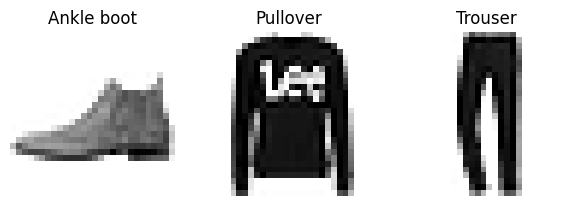

In [43]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

## **2. Building a Regression MLP Using the Sequential API**

In [44]:
# using calafornia housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

In [45]:
tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)

history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

mse_test, rmse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20


c:\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.8891 - loss: 0.7905 - val_RootMeanSquaredError: 0.6186 - val_loss: 0.3826
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6070 - loss: 0.3684 - val_RootMeanSquaredError: 0.6442 - val_loss: 0.4150
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5890 - loss: 0.3469 - val_RootMeanSquaredError: 0.7502 - val_loss: 0.5628
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5764 - loss: 0.3323 - val_RootMeanSquaredError: 0.6727 - val_loss: 0.4526
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5734 - loss: 0.3288 - val_RootMeanSquaredError: 0.6639 - val_loss: 0.4408
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5667 - loss: 0.3211 - val_RootMeanSquaredError: 0.8627 - val_loss: 0.7442
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - RootMeanSquaredError: 0.5593 - loss: 0.3128 -

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,822 (65.72 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 11,204 (43.77 KB)

In [47]:
hidden1 = model.layers[1]
hidden1.name

'dense_3'

In [48]:
weights, biases = hidden1.get_weights()

print(weights)
print(weights.shape)
print('-' * 80)
print(biases)
print(biases.shape)

[[ 0.2701016  -0.27763     0.2567717  -0.28419384 -0.00920966 -0.09214901
   0.1082549   0.02257044 -0.11336397 -0.22755343  0.18719006  0.2964299
   0.21523418  0.28078046  0.21869554  0.19250156  0.20420764 -0.18718556
  -0.27987623  0.16550119 -0.2363331   0.22287029 -0.00244329  0.03802054
   0.1533255  -0.33666402 -0.06202162 -0.01284612  0.2957565   0.05903435
   0.1341323   0.20832062  0.136819    0.01135361 -0.02662563  0.32393813
  -0.0224449   0.05343958  0.10086909  0.20605406 -0.33116987 -0.01372461
  -0.00974273 -0.0464646  -0.005595    0.33291885 -0.10676913 -0.03876811
   0.04587727  0.11250193]
 [ 0.16108406  0.06826336  0.13877982  0.13863382 -0.01144994  0.07186228
   0.08280329 -0.12192297 -0.17105454  0.11286665 -0.10509261  0.28025985
   0.24583648  0.00128298  0.24114516  0.15697345 -0.04175524 -0.01124082
  -0.30196074 -0.1707626  -0.15585245  0.00089139 -0.19555986 -0.04619374
  -0.28388464  0.14376824  0.33758757 -0.05898134  0.13730186 -0.23209134
   0.0373375

In [49]:
print(history.params)
print(history.epoch)

{'verbose': 'auto', 'epochs': 20, 'steps': 363}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [50]:
rmse_test

0.5387855768203735

In [51]:
y_pred

array([[0.45608294],
       [1.2363967 ],
       [5.034134  ]], dtype=float32)

In [52]:
y_test[:3]

array([0.477  , 0.458  , 5.00001])

In [53]:
y_actual = y_test[:3]
y_pred = model.predict(X_test[:3])

for i in range(3):
    print(f"Sample {i+1}: Actual = {y_actual[i]:.3f}, Predicted = {y_pred[i][0]:.3f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Sample 1: Actual = 0.477, Predicted = 0.456
Sample 2: Actual = 0.458, Predicted = 1.236
Sample 3: Actual = 5.000, Predicted = 5.034


## **3. Building Complex Models Using the Functional API**

Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network connects all or part of the inputs directly to the output layer.

In [54]:
# reset the name counters and make the code reproducible
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [55]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input_], outputs=[output])

In [56]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,256 (4.91 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 17 (72.00 B)

In [57]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    loss="mse", 
    optimizer=optimizer, 
    metrics=["RootMeanSquaredError"]
)
normalization_layer.adapt(X_train)

history = model.fit(
    X_train, 
    y_train, 
    epochs=20,
    validation_data=(X_valid, y_valid)
)

mse_test = model.evaluate(X_test, y_test)
y_pred = model.predict(X_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.1448 - loss: 1.3106 - val_RootMeanSquaredError: 1.4723 - val_loss: 2.1677
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7231 - loss: 0.5229 - val_RootMeanSquaredError: 1.3326 - val_loss: 1.7759
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6600 - loss: 0.4356 - val_RootMeanSquaredError: 1.3964 - val_loss: 1.9501
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6279 - loss: 0.3942 - val_RootMeanSquaredError: 1.0965 - val_loss: 1.2023
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6213 - loss: 0.3860 - val_RootMeanSquaredError: 1.5152 - val_loss: 2.2957
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6053 - loss: 0.3664 - val_RootMeanSquaredError: 1.2508 - val_loss: 1.5646
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6020 - los

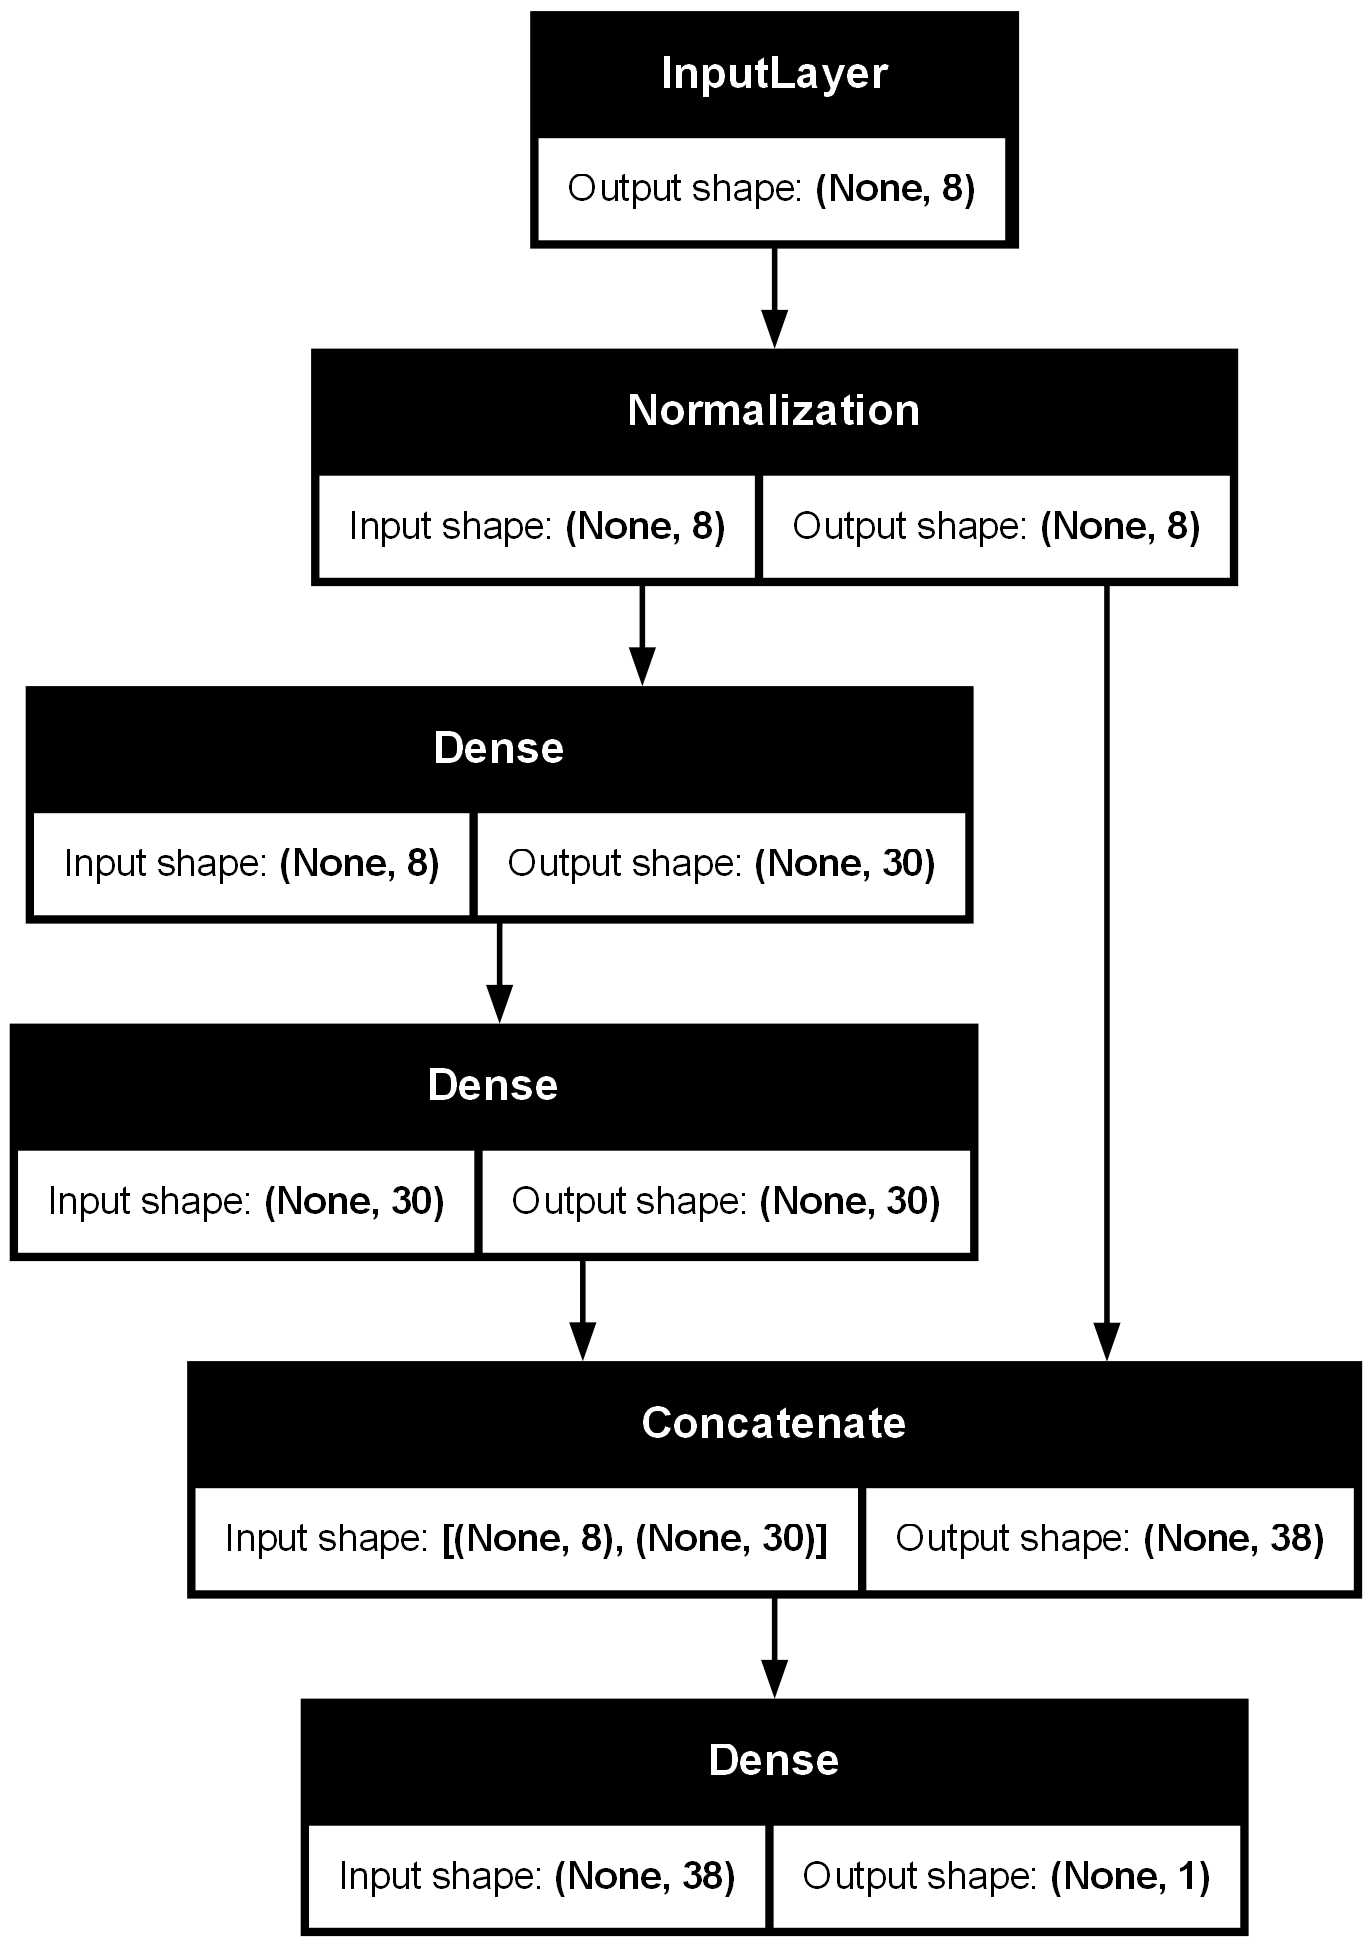

In [58]:
tf.keras.utils.plot_model(model, "california_housing_model.png", show_shapes=True)

In [59]:
# with 2 inputs

input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7

norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()

norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [60]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    loss="mse", 
    optimizer=optimizer, 
    metrics=["RootMeanSquaredError"]
    )

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

history = model.fit(
    (X_train_wide, X_train_deep), 
    y_train, 
    epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), y_valid)
    )

mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.0729 - loss: 1.1511 - val_RootMeanSquaredError: 0.7467 - val_loss: 0.5575
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6859 - loss: 0.4704 - val_RootMeanSquaredError: 0.6506 - val_loss: 0.4233
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6572 - loss: 0.4319 - val_RootMeanSquaredError: 0.8095 - val_loss: 0.6552
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6430 - loss: 0.4135 - val_RootMeanSquaredError: 0.6466 - val_loss: 0.4180
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6359 - loss: 0.4044 - val_RootMeanSquaredError: 0.9740 - val_loss: 0.9486
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6285 - loss: 0.3950 - val_RootMeanSquaredError: 1.0687 - val_loss: 1.1421
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6278 - los

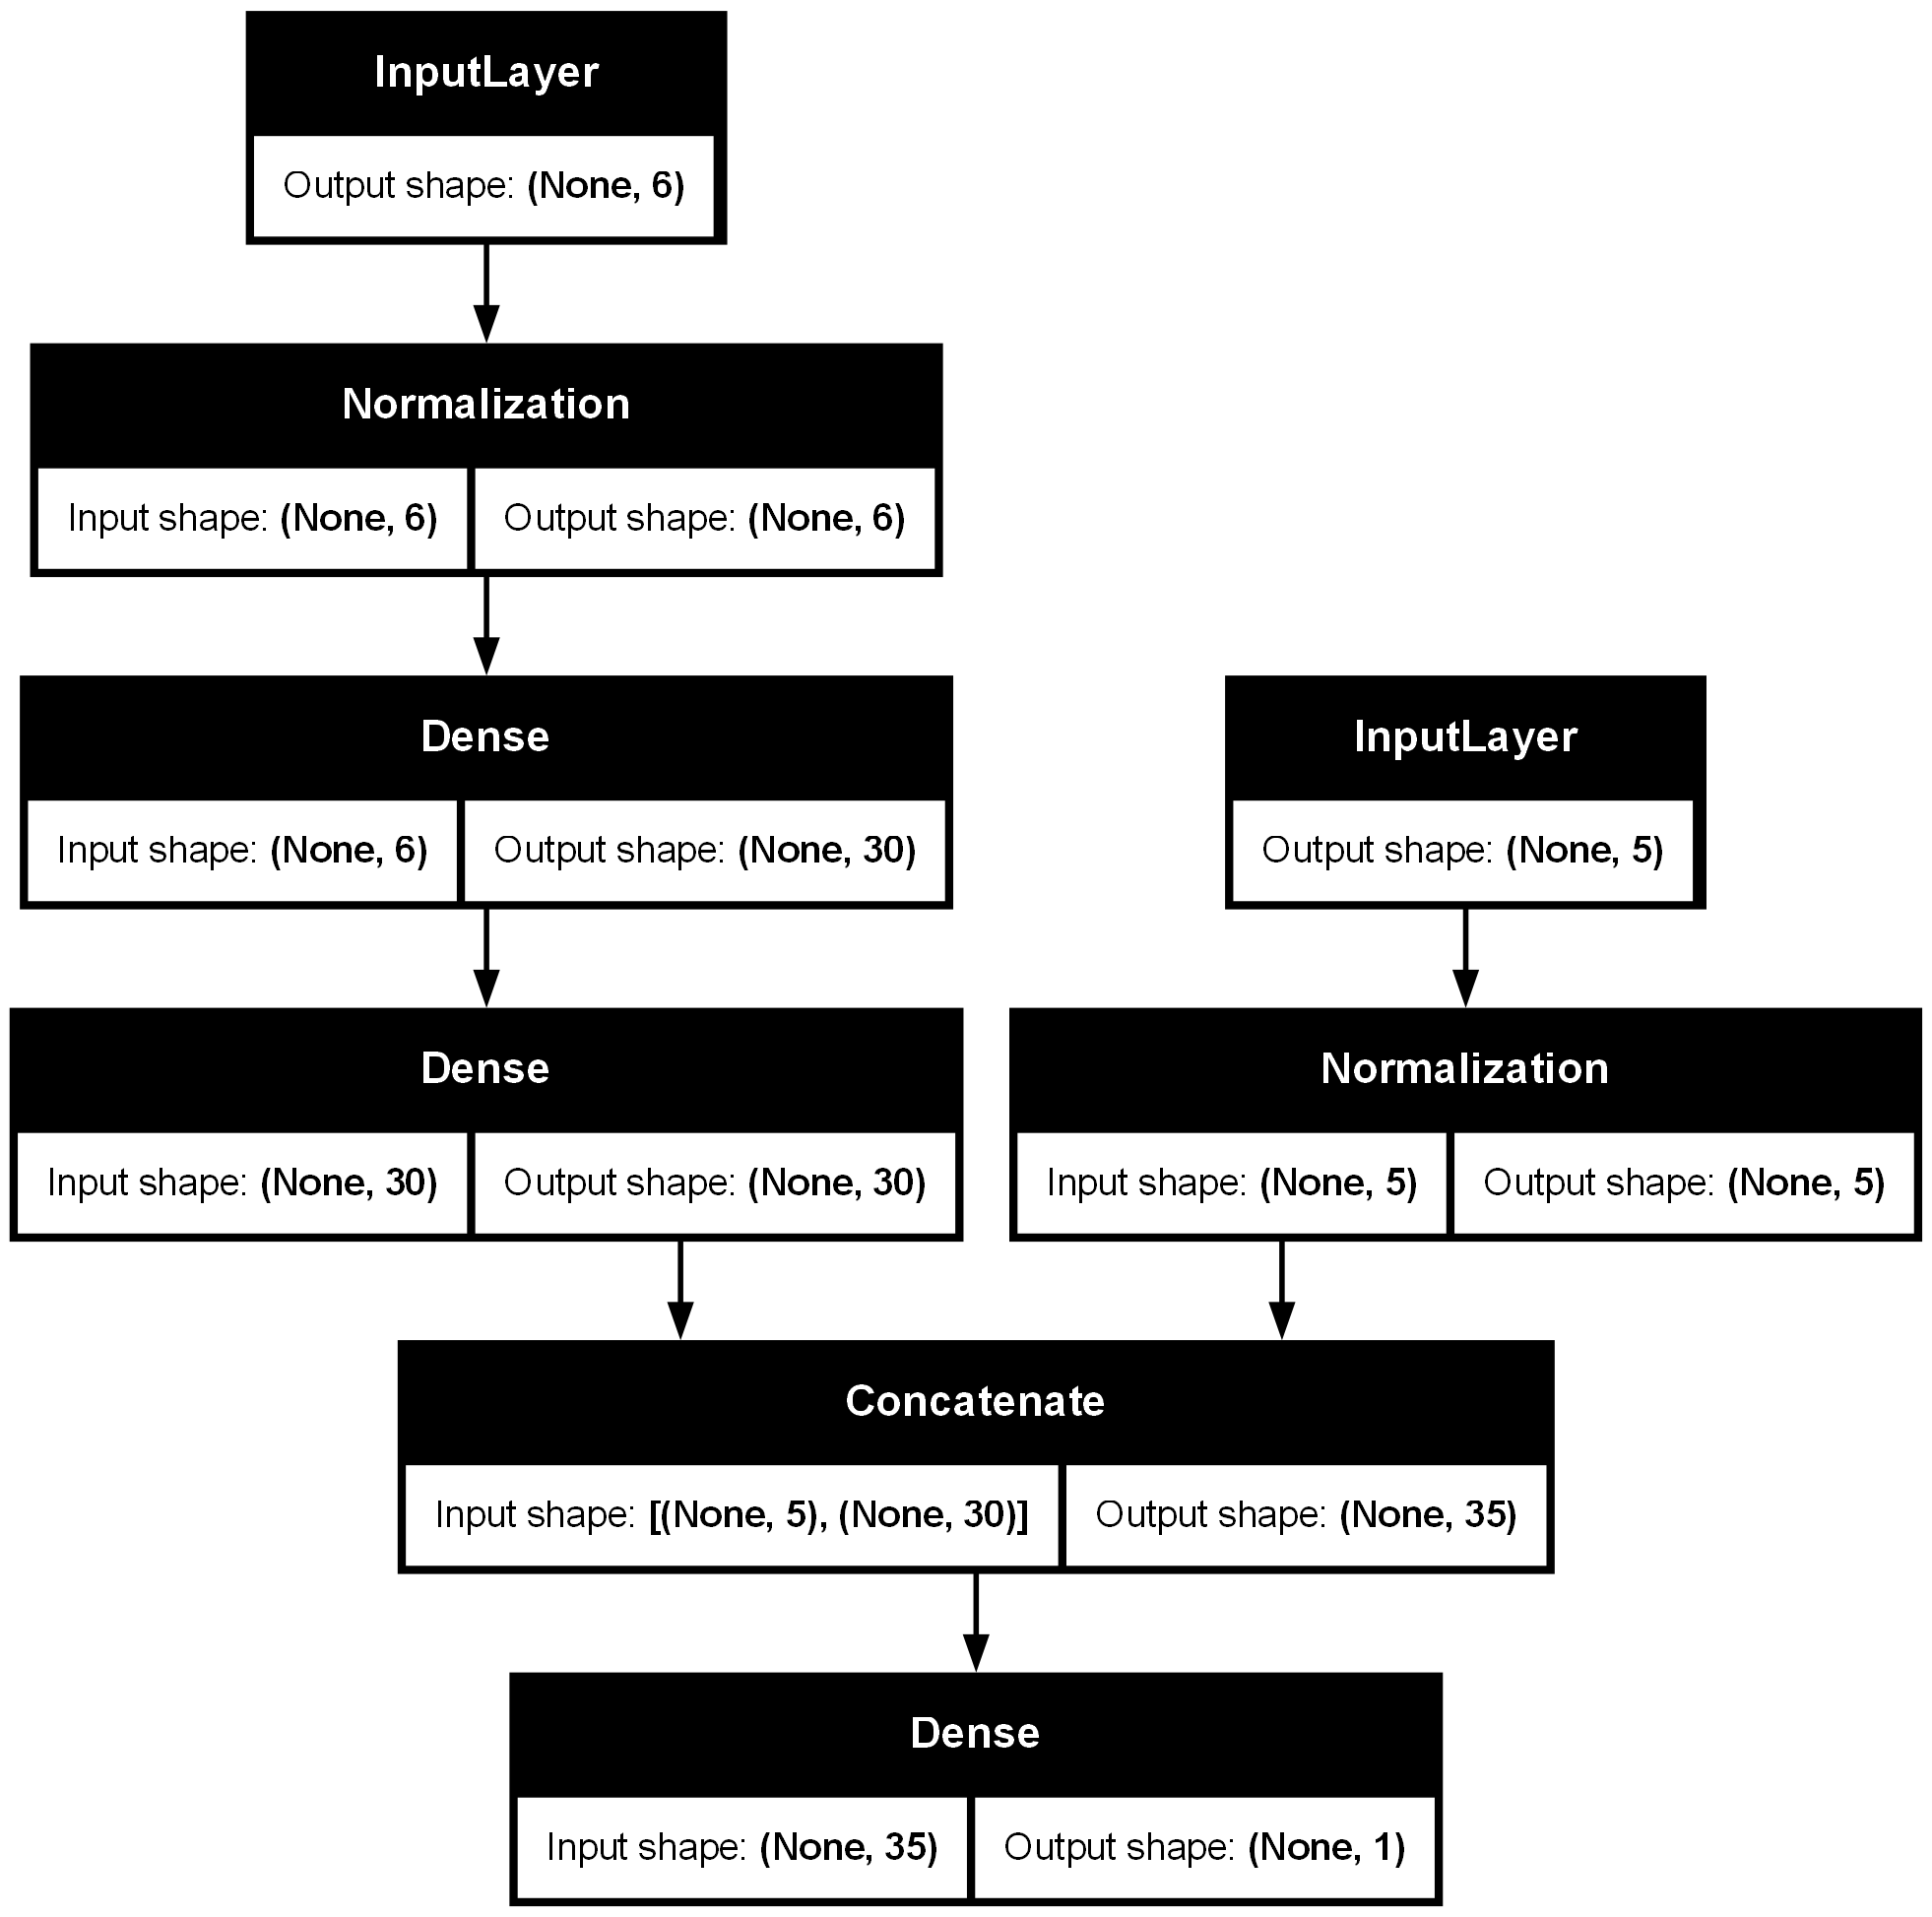

In [61]:
tf.keras.utils.plot_model(model, "california_housing_model_2inputs.png", show_shapes=True)

you may want to locate and classify the main object in a picture. This is both a regression task (finding the coordinates of the object’s center, as well as its width and height) and a classification task. We can use two output layer

In [62]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [63]:
input_wide = tf.keras.layers.Input(shape=[5])  # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6])  # features 2 to 7

norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()

norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1, name="main_output")(concat)
aux_output = tf.keras.layers.Dense(1, name="aux_output")(hidden2)

model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output, aux_output])

In [64]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 6)         │         13 │ input_layer_1[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        210 │ normalization_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 5)         │         11 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_output (Dense) │ (None, 1)         │         36 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_output (Dense)  │ (None, 1)         │         31 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,231 (4.82 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

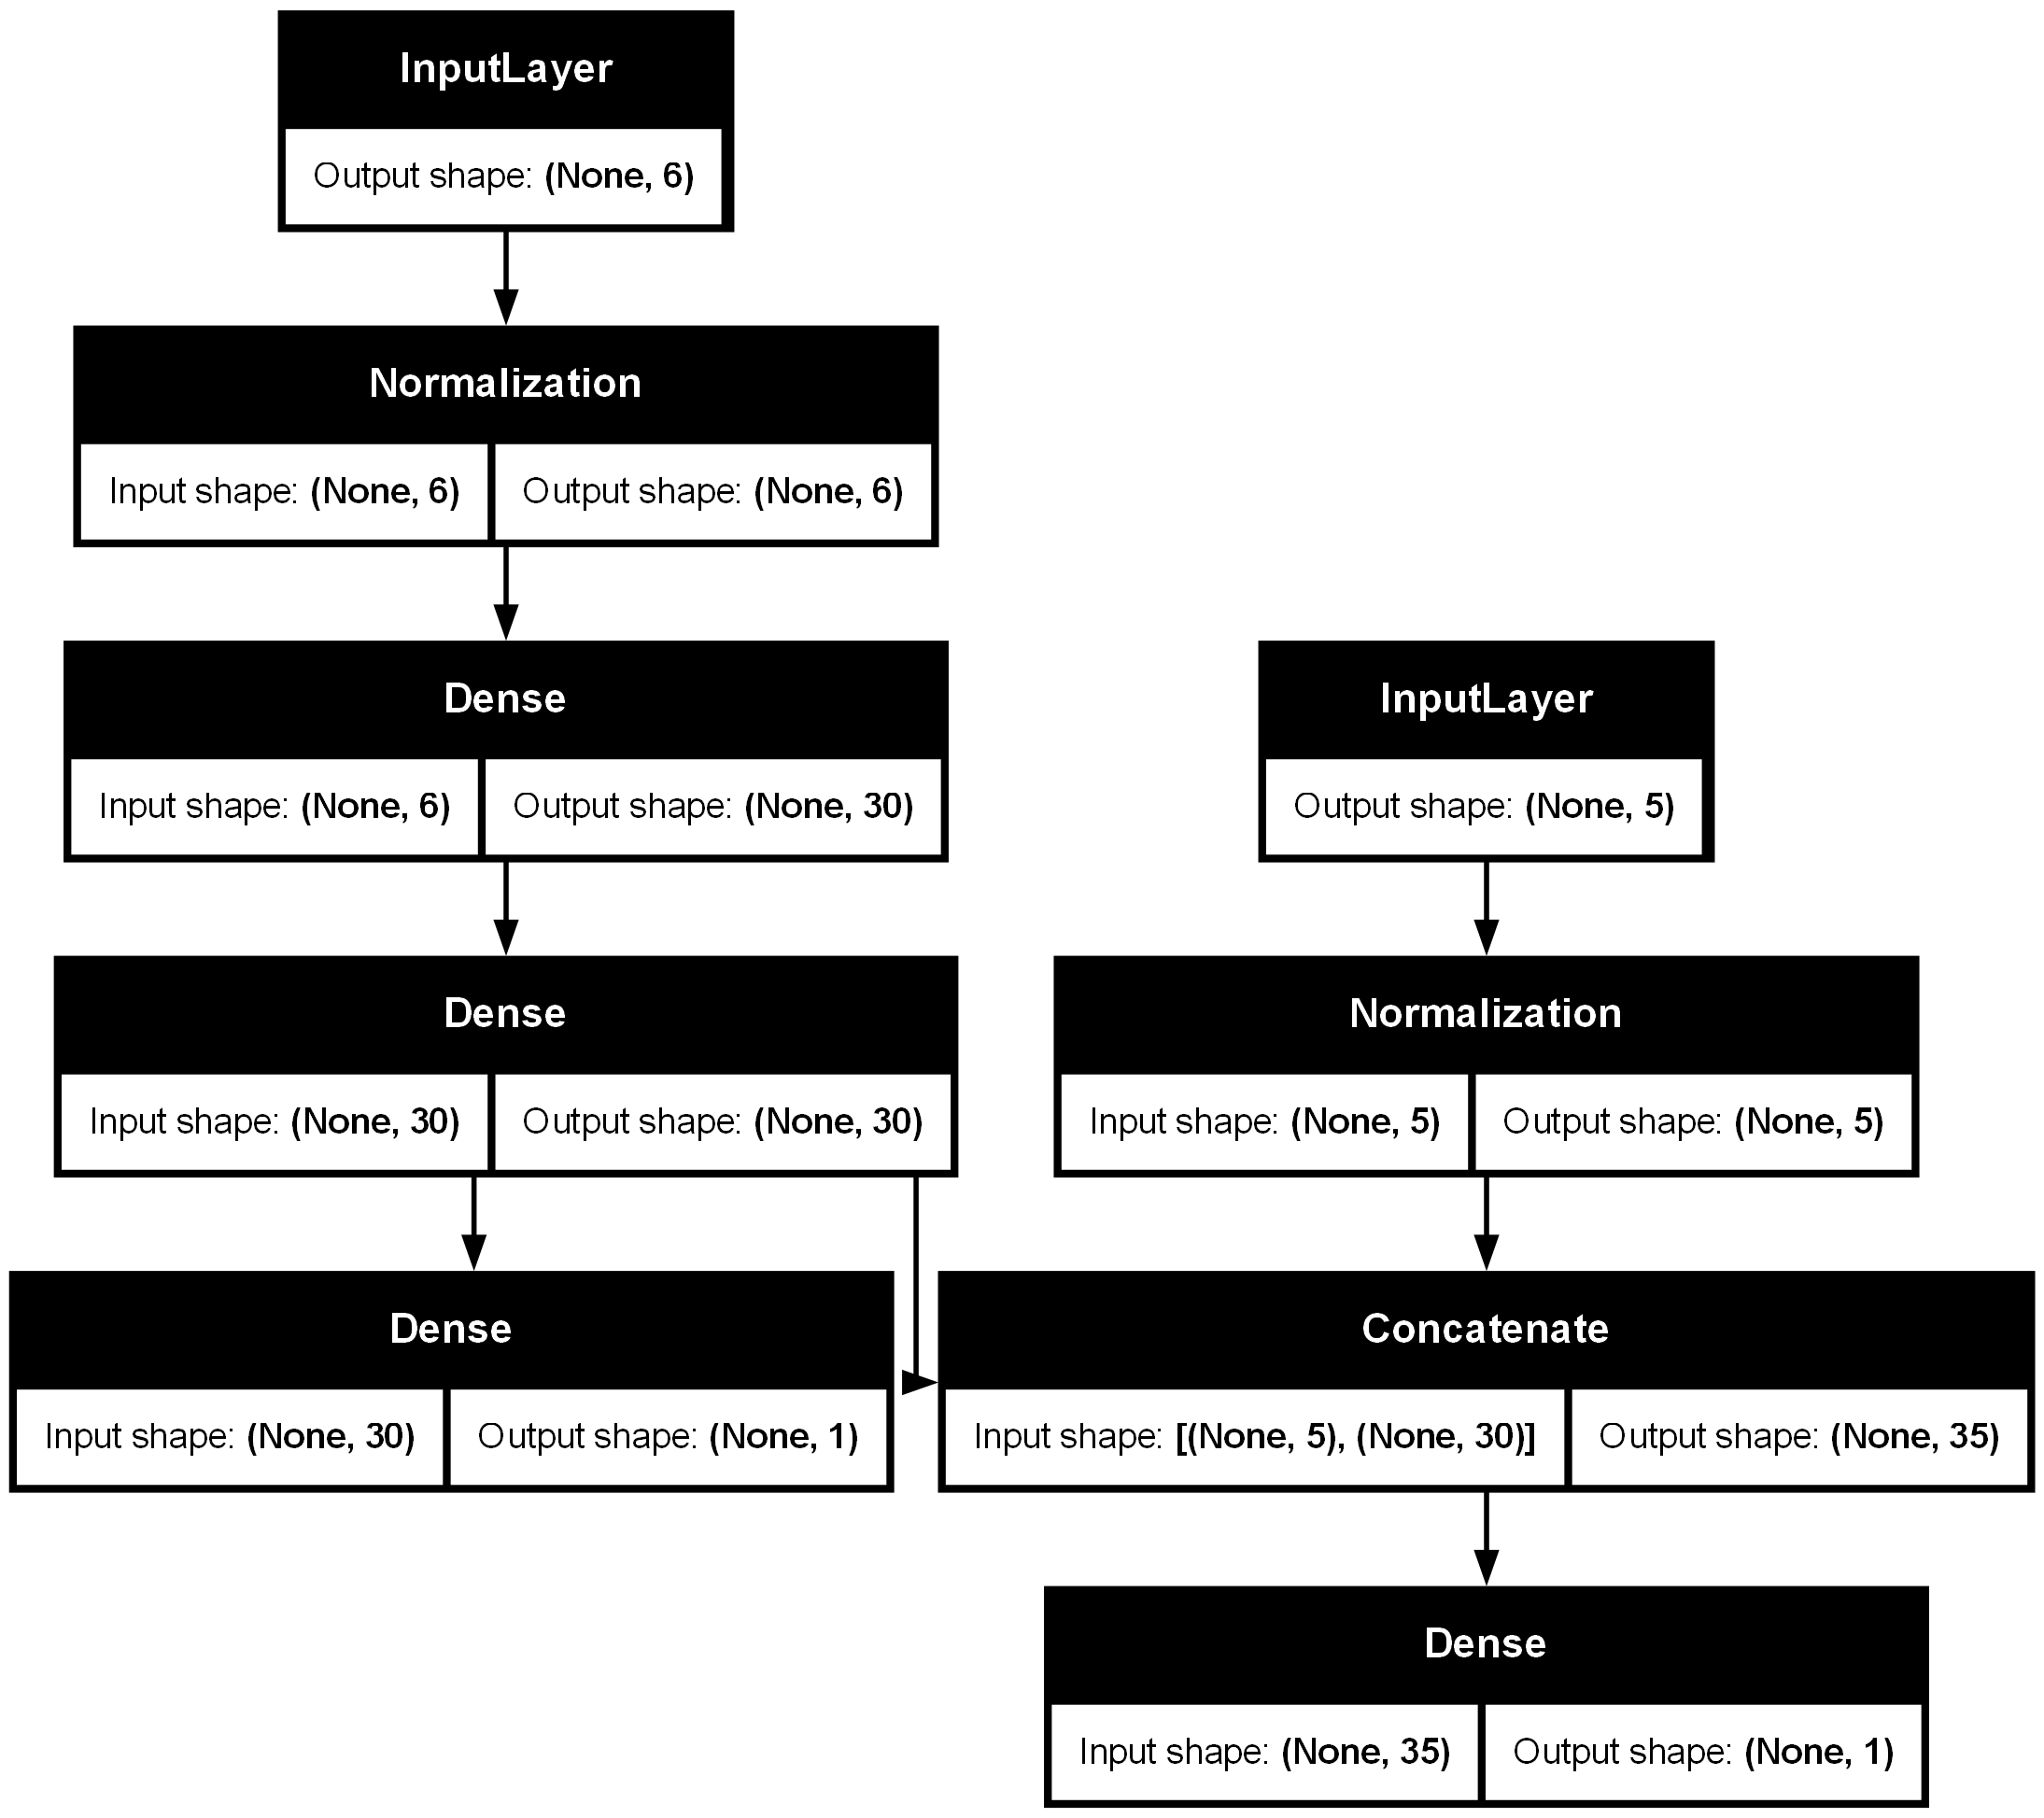

In [65]:
tf.keras.utils.plot_model(model, "california_housing_model_2output.png", show_shapes=True)

In [66]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    loss=("mse", "mse"), 
    loss_weights=(0.9, 0.1), 
    optimizer=optimizer,
    metrics=["RootMeanSquaredError", "RootMeanSquaredError"]
)

In [67]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

history = model.fit(
    (X_train_wide, X_train_deep), 
    (y_train, y_train), 
    epochs=20,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - aux_output_RootMeanSquaredError: 1.4426 - aux_output_loss: 2.0805 - loss: 1.6377 - main_output_RootMeanSquaredError: 1.2603 - main_output_loss: 1.5879 - val_aux_output_RootMeanSquaredError: 1.1294 - val_aux_output_loss: 1.2754 - val_loss: 1.0370 - val_main_output_RootMeanSquaredError: 1.0052 - val_main_output_loss: 1.0101
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_RootMeanSquaredError: 0.8917 - aux_output_loss: 0.7950 - loss: 0.5300 - main_output_RootMeanSquaredError: 0.7075 - main_output_loss: 0.5006 - val_aux_output_RootMeanSquaredError: 0.9629 - val_aux_output_loss: 0.9269 - val_loss: 0.5071 - val_main_output_RootMeanSquaredError: 0.6785 - val_main_output_loss: 0.4602
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_RootMeanSquaredError: 0.8055 - aux_output_loss: 0.6487 - loss: 0.4442 - main_output_RootMeanSquaredError: 0.6492 - main_output_loss: 0.4216 - val_aux_output_RootMeanSquaredError: 

In [68]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - aux_output_RootMeanSquaredError: 0.6302 - aux_output_loss: 0.3977 - loss: 0.3353 - main_output_RootMeanSquaredError: 0.5731 - main_output_loss: 0.3281


In [69]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [70]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep))
y_pred = dict(zip(model.output_names, y_pred_tuple))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [71]:
y_pred

{'main_output': array([[0.47494197],
        [1.1017089 ],
        [3.5583565 ]], dtype=float32),
 'aux_output': array([[0.56838727],
        [0.94775665],
        [3.216945  ]], dtype=float32)}

## **4. Using the Subclassing API to Build Dynamic Models**

Some models involve loops, varying shapes, conditional branching, and other dynamic behaviors. For such cases, or simply if you prefer a more imperative programming style, the **Subclassing API** is for you.

In [72]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)
        
    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

tf.random.set_seed(42)
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

In [73]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    loss=["mse", "mse"], 
    loss_weights=[0.9, 0.1], 
    optimizer=optimizer,
    metrics=["RootMeanSquaredError", "RootMeanSquaredError"]
)

model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)

history = model.fit(
    (X_train_wide, X_train_deep), 
    (y_train, y_train), 
    epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.1843 - RootMeanSquaredError_1: 1.3678 - loss: 1.4495 - mse_loss: 1.8703 - val_RootMeanSquaredError: 0.8049 - val_RootMeanSquaredError_1: 1.1216 - val_loss: 0.7088 - val_mse_loss: 1.2577
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.7077 - RootMeanSquaredError_1: 0.9039 - loss: 0.5325 - mse_loss: 0.8170 - val_RootMeanSquaredError: 0.7248 - val_RootMeanSquaredError_1: 0.9629 - val_loss: 0.5655 - val_mse_loss: 0.9269
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6588 - RootMeanSquaredError_1: 0.8066 - loss: 0.4557 - mse_loss: 0.6507 - val_RootMeanSquaredError: 1.0977 - val_RootMeanSquaredError_1: 1.0672 - val_loss: 1.1983 - val_mse_loss: 1.1385
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6394 - RootMeanSquaredError_1: 0.7648 - loss: 0.4264 - mse_loss: 0.5850 - val_RootMeanSquaredError: 1.0697 - val_RootMeanSquaredEr

## **5. Saving and Restoring a Model**

1. When using the Sequential API or the Functional API, saving a trained Keras model is as simple as it gets

2. Keras now recommends using the .keras format to save models, and the h5 format for weights. Therefore I have updated the code in this section to first show what you need to change if you still want to use TensorFlow's SavedModel format, and then how you can use the recommended formats.

In [74]:
# delete the directory, in case it already exists
import shutil

shutil.rmtree("my_keras_model", ignore_errors=True)

Keras's model.save() method no longer supports TensorFlow's SavedModel format. However, you can still export models to the SavedModel format using model.export() like this:

In [75]:
model.export("my_keras_model")

INFO:tensorflow:Assets written to: my_keras_model\assets


INFO:tensorflow:Assets written to: my_keras_model\assets


Saved artifact at 'my_keras_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Tuple[TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)]
Output Type:
  Tuple[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2431954112144: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2431954120976: TensorSpec(shape=(1, 5), dtype=tf.float32, name=None)
  2431951075664: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2431954113104: TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
  2431951065104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431951068560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431951074896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431951068752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431951071632: TensorSpec(shape=(), dtype=tf.resou

In Keras 3, it is no longer possible to load a TensorFlow SavedModel as a Keras model. However, you can load a SavedModel as a tf.keras.layers.TFSMLayer layer, but be aware that this layer can only be used for inference: no training.

In [76]:
tfsm_layer = tf.keras.layers.TFSMLayer("my_keras_model")
y_pred_main, y_pred_aux = tfsm_layer((X_new_wide, X_new_deep))

Keras now requires the saved weights to have the .weights.h5 extension. There are no longer saved using the SavedModel format.

In [77]:
model.save_weights("my_weights.weights.h5")

In [78]:
model.load_weights("my_weights.weights.h5")

To save a model using the .keras format, simply use model.save():

In [79]:
model.save("my_model.keras")

To load a .keras model, use the tf.keras.models.load_model() function. If the model uses any custom object, you must pass them to the function via the custom_objects argument:

In [80]:
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

### **1. Save during training (ModelCheckpoint)**

But what if training lasts several hours? This is quite common, especially when training on large datasets. In this case, you should not only save your model at the end of training, but also save checkpoints at regular intervals during training, to avoid losing everything if your computer crashes. But how can you tell the fit() method to save checkpoints?

In [81]:
shutil.rmtree("my_checkpoints", ignore_errors=True)

In [82]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_checkpoints.weights.h5",
    save_weights_only=True
)

history = model.fit(
    (X_train_wide, X_train_deep), 
    (y_train, y_train), 
    epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb]
)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6151 - RootMeanSquaredError_1: 0.6950 - loss: 0.3888 - mse_loss: 0.4831 - val_RootMeanSquaredError: 1.4387 - val_RootMeanSquaredError_1: 1.1844 - val_loss: 2.0031 - val_mse_loss: 1.4023
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6050 - RootMeanSquaredError_1: 0.6836 - loss: 0.3762 - mse_loss: 0.4674 - val_RootMeanSquaredError: 1.2788 - val_RootMeanSquaredError_1: 1.3221 - val_loss: 1.6467 - val_mse_loss: 1.7471
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6029 - RootMeanSquaredError_1: 0.6780 - loss: 0.3731 - mse_loss: 0.4597 - val_RootMeanSquaredError: 1.1809 - val_RootMeanSquaredError_1: 1.0034 - val_loss: 1.3558 - val_mse_loss: 1.0065
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5947 - RootMeanSquaredError_1: 0.6683 - loss: 0.3629 - mse_loss: 0.4467 - val_RootMeanSquaredError: 1.1189 - val_RootMeanSquaredEr

You can combine both callbacks to save checkpoints of your model (in case your computer crashes) and interrupt training early when there is no more progress (to avoid wasting time and resources)

In [83]:
early_stopping_db = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    (X_train_wide, X_train_deep), 
    (y_train, y_train), 
    epochs=100,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_db]
)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5802 - RootMeanSquaredError_1: 0.6388 - loss: 0.3438 - mse_loss: 0.4082 - val_RootMeanSquaredError: 1.0640 - val_RootMeanSquaredError_1: 1.1550 - val_loss: 1.1524 - val_mse_loss: 1.3335
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5759 - RootMeanSquaredError_1: 0.6338 - loss: 0.3387 - mse_loss: 0.4018 - val_RootMeanSquaredError: 1.0051 - val_RootMeanSquaredError_1: 1.2473 - val_loss: 1.0648 - val_mse_loss: 1.5552
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5744 - RootMeanSquaredError_1: 0.6304 - loss: 0.3367 - mse_loss: 0.3974 - val_RootMeanSquaredError: 0.8632 - val_RootMeanSquaredError_1: 1.0914 - val_loss: 0.7898 - val_mse_loss: 1.1908
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5709 - RootMeanSquaredError_1: 0.6277 - loss: 0.3328 - mse_loss: 0.3940 - val_RootMeanSquaredError: 0.7996 - val_RootMeanSquar

custom callback to display the ratiobetween the validation loss and the training loss during training 

In [84]:
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [85]:
val_train_ratio_cb = PrintValTrainRatioCallback()

history = model.fit(
    (X_train_wide, X_train_deep), 
    (y_train, y_train), 
    epochs=10,
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),
    callbacks=[val_train_ratio_cb], 
    verbose=0
)

Epoch=0, val/train=1.14
Epoch=1, val/train=1.11
Epoch=2, val/train=1.41
Epoch=3, val/train=1.36
Epoch=4, val/train=1.36
Epoch=5, val/train=1.52
Epoch=6, val/train=1.36
Epoch=7, val/train=1.22
Epoch=8, val/train=1.10
Epoch=9, val/train=1.22


## **6. Using TensorBoard for Visualization**

In [86]:
from tensorflow.keras.callbacks import TensorBoard
import datetime

In [87]:
# create a log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_cb = TensorBoard(log_dir=log_dir, profile_batch=(100, 200))

In [88]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(
    loss="mse", 
    optimizer=optimizer, 
    metrics=["RootMeanSquaredError"]
)
norm_layer.adapt(X_train)

c:\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [89]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=20,
    validation_data=(X_valid, y_valid),
    callbacks=[tensorboard_cb]
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 1.4160 - loss: 2.0051 - val_RootMeanSquaredError: 0.9445 - val_loss: 0.8921
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.8596 - loss: 0.7390 - val_RootMeanSquaredError: 0.8347 - val_loss: 0.6967
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.8157 - loss: 0.6654 - val_RootMeanSquaredError: 0.7996 - val_loss: 0.6394
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7880 - loss: 0.6210 - val_RootMeanSquaredError: 0.7699 - val_loss: 0.5928
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.7629 - loss: 0.5821 - val_RootMeanSquaredError: 0.7428 - val_loss: 0.5518
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.7398 - loss: 0.5474 - val_RootMeanSquaredError: 0.7178 - val_loss: 0.5153
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.7189 - los

You can use also visualize histograms, images, text, and even listen to audio using TensorBoard:

In [90]:
test_logdir = tensorboard_cb.log_dir
writer = tf.summary.create_file_writer(test_logdir)

with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100  # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        images = np.random.rand(2, 32, 32, 3) * step / 1000  # gets brighter
        tf.summary.image("my_images", images, step=step)
        
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)
        
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

When you stop this Jupyter kernel (a.k.a. Runtime), it will automatically stop the TensorBoard server as well. Another way to stop the TensorBoard server is to kill it, if you are running on Linux or MacOSX. First, you need to find its process ID:

In [91]:
# lists all running TensorBoard server instances
from tensorboard import notebook

notebook.list()

Known TensorBoard instances:
  - port 6006: logdir logs (started 3 days, 22:17:00 ago; pid 4760)


to kil the task
taskkill /PID <pid> /F

# **Fine-Tuning Neural Network Hyperparameters**

We can use GridSreachCC or RandomizedSearchCV to explore the hyperparameters space

In [92]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

## **1. Keras Tuner**

An easy-to-use hyperparameter optimization library by Google for Keras models, with a hosted service for visualization and analysis.

In [93]:
import keras_tuner as kt

def build_model(hp):

    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2,
                             sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model.add(tf.keras.layers.Dense(10, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy", 
        optimizer=optimizer,
        metrics=["accuracy"]
        )
    
    return model

In [94]:
random_search_tuner = kt.RandomSearch(
    build_model, 
    objective="val_accuracy", 
    max_trials=5, 
    overwrite=True,
    directory="my_fashion_mnist", 
    project_name="my_rnd_search", 
    seed=42
    )

random_search_tuner.search(
    X_train, y_train, 
    epochs=10,
    validation_data=(X_valid, y_valid)
    )

Trial 5 Complete [00h 00m 34s]
val_accuracy: 0.8302000164985657

Best val_accuracy So Far: 0.8479999899864197
Total elapsed time: 00h 02m 56s


In [98]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [99]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [100]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8479999899864197


In [101]:
best_trial.metrics.get_last_value("val_accuracy")

0.8479999899864197

In [102]:
best_model.fit(X_train_full, y_train_full, epochs=10)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8755 - loss: 0.3381
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8801 - loss: 0.3244
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8836 - loss: 0.3146
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8872 - loss: 0.3050
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8906 - loss: 0.2964
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8928 - loss: 0.2892
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8953 - loss: 0.2823
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8979 - loss: 0.2756
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9001 - loss: 0.2693
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9025 - loss: 0.2638
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.4134


## **2. Hyperopt**

A popular library for optimizing over all sorts of complex search spaces (including real values, such as the learning rate, and discrete values, such as the number of layers).

In [ ]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, X, y, **kwargs):
        if hp.Boolean("normalize"):
            norm_layer = tf.keras.layers.Normalization()
            norm_layer.adapt(X)
            X = norm_layer(X)
        return model.fit(X, y, **kwargs)

# **Exercises**

## **1.**

1. Suppose you have an MLP composed of one input layer with 10 passthrough neurons, followed by one hidden layer with 50 artificial neurons, and finally one output layer with 3 artificial neurons. All artificial neurons use the ReLU activation function.

- What is the shape of the input matrix X?
- What are the shapes of the hidden layer’s weight vector $W_{b}$ and its bias vector $b_{h}$?
- What are the shapes of the output layer’s weight vector $W_{o}$ and its bias vector $b_{o}$?
- What is the shape of the network’s output matrix Y?
- Write the equation that computes the network’s output matrix Y as a function of $X, W_{h}, b_{h}, W_{o}, b_{o}$

1. The shape of the input matrix X is m × 10, where m represents the training batch size.
2. The shape of the hidden layer's weight matrix Wh is 10 × 50, and the length of its bias vector bh is 50.
3. The shape of the output layer's weight matrix Wo is 50 × 3, and the length of its bias vector bo is 3.
4. The shape of the network's output matrix Y is m × 3.
5. Y = ReLU(ReLU(X Wh + bh) Wo + bo). Recall that the ReLU function just sets every negative number in the matrix to zero. Also note that when you are adding a bias vector to a matrix, it is added to every single row in the matrix, which is called broadcasting.

## **2.**

2. Train a deep MLP on the MNIST dataset (you can load it using keras.data
sets.mnist.load_data()). See if you can get over 98% precision. Try searching
for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Try adding all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.

In [14]:
import tensorflow as tf
from tensorflow import keras

(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
X_train_full.shape

(60000, 28, 28)

In [16]:
X_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [17]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Let's plot an image using Matplotlib's imshow() function, with a 'binary' color map:

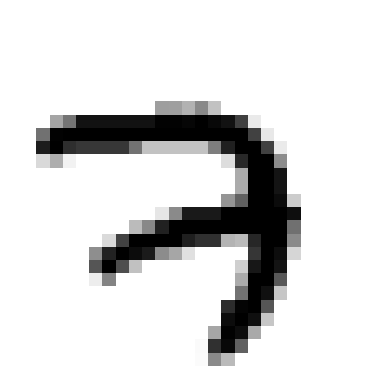

In [19]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a class_names array:

In [20]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [22]:
X_valid.shape

(5000, 28, 28)

In [23]:
X_test.shape

(10000, 28, 28)

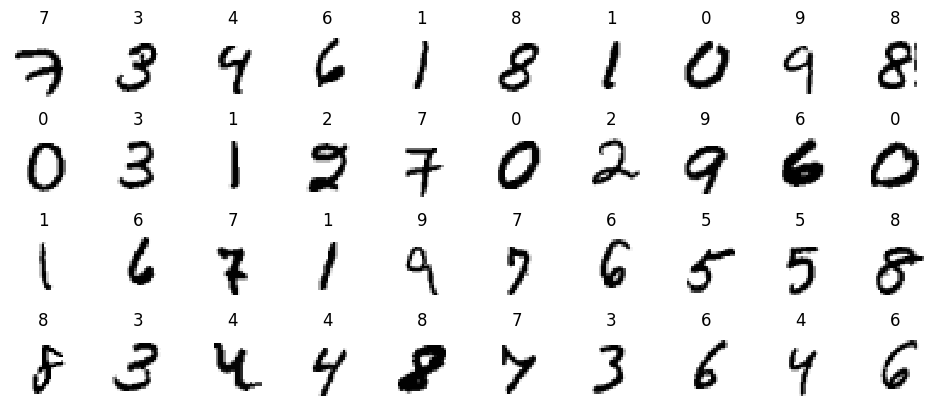

In [24]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [26]:
K = tf.keras.backend
import numpy as np

K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [33]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()

print("Layer Name: ", hidden1.name)
print(weights)
print(weights.shape)
print('-' * 80)
print(biases)
print(biases.shape)

Layer Name:  dense
[[-0.04706988 -0.03956478 -0.0431366  ...  0.03452042  0.04019022
   0.06641081]
 [ 0.02616135  0.06484899 -0.00873758 ...  0.0307182  -0.04623061
   0.02116583]
 [-0.04646748 -0.05060963 -0.01129981 ...  0.02966274  0.06418312
  -0.04400646]
 ...
 [-0.02624848  0.06446294 -0.05439639 ... -0.04427814 -0.03521065
   0.03457306]
 [ 0.02105338 -0.00612736  0.05845471 ... -0.06787707  0.04597554
   0.0397188 ]
 [-0.05545896  0.05490941 -0.06774044 ... -0.06794897  0.06910443
   0.07069187]]
(784, 300)
--------------------------------------------------------------------------------
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

In [39]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

model.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer=optimizer,
    metrics=["accuracy"]
)

expon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [40]:
history = model.fit(
    X_train, y_train, 
    epochs=1,
    validation_data=(X_valid, y_valid),
    callbacks=[expon_lr]
)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5848 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


We can now plot the loss as a functionof the learning rate:

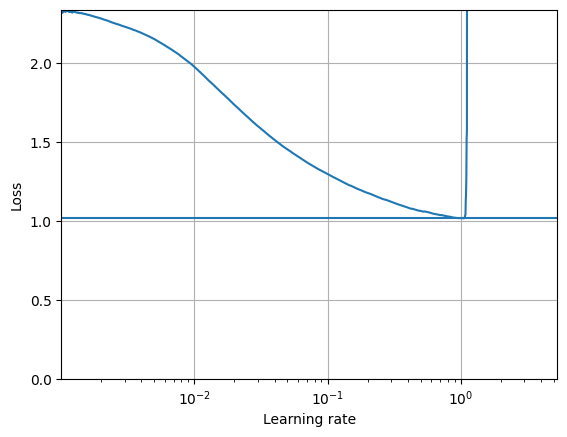

In [43]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

plt.show()

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [47]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [49]:
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1)

model.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [51]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir="logs/exp1",
    histogram_freq=1
)

history = model.fit(
    X_train, y_train, 
    epochs=100,
    validation_data=(X_valid, y_valid),
    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb]
)

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9278 - loss: 0.2329 - val_accuracy: 0.9690 - val_loss: 0.1031
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9721 - loss: 0.0916 - val_accuracy: 0.9748 - val_loss: 0.0915
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9825 - loss: 0.0581 - val_accuracy: 0.9784 - val_loss: 0.0743
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9868 - loss: 0.0414 - val_accuracy: 0.9772 - val_loss: 0.0907
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9899 - loss: 0.0329 - val_accuracy: 0.9770 - val_loss: 0.0904
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9899 - loss: 0.0302 - val_accuracy: 0.9766 - val_loss: 0.1062
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9923 - loss: 0.0248 - val_accuracy: 0.9782 - val_loss: 0.0937
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9941 -

In [52]:
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback to best model
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0730


[0.07298503071069717, 0.9787999987602234]